In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/fake_job_postings.csv')
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [3]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

### Columns to drop
- job id
- department
- salary_range

In [9]:
# uniques in categorical columns
categorical_cols = ['location', 'company_profile', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].nunique()}   |  Total non-null values in '{col}': {df[col].count()}")


Unique values in 'location': 3105   |  Total non-null values in 'location': 17534
Unique values in 'company_profile': 1709   |  Total non-null values in 'company_profile': 14572
Unique values in 'requirements': 11967   |  Total non-null values in 'requirements': 15184
Unique values in 'benefits': 6204   |  Total non-null values in 'benefits': 10668
Unique values in 'employment_type': 5   |  Total non-null values in 'employment_type': 14409
Unique values in 'required_experience': 7   |  Total non-null values in 'required_experience': 10830
Unique values in 'required_education': 13   |  Total non-null values in 'required_education': 9775
Unique values in 'industry': 131   |  Total non-null values in 'industry': 12977
Unique values in 'function': 37   |  Total non-null values in 'function': 11425


- We can encode `employment_type`, `required_experience`, `function` and `required_education` columns

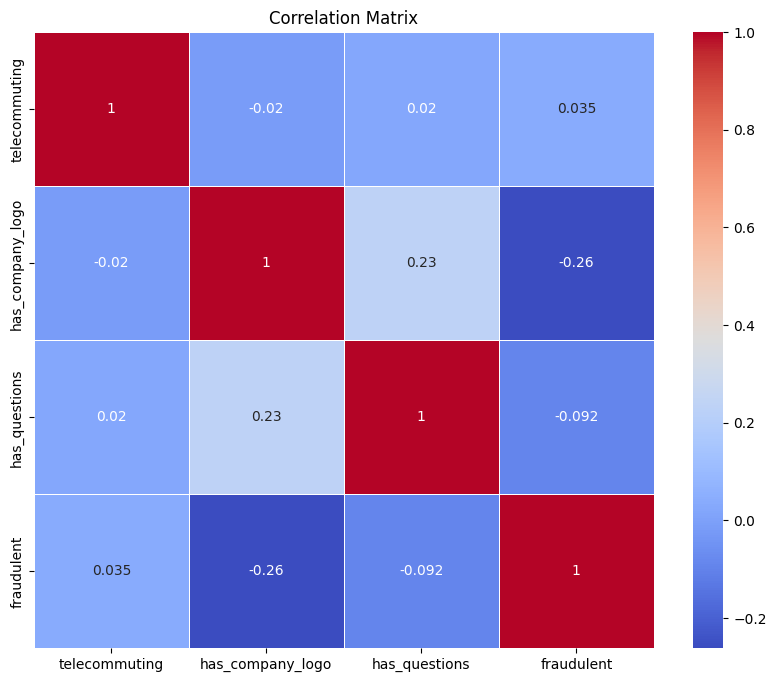

In [11]:
# correlation analysis of numerical features
import seaborn as sns
numerical_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

- Company log has most correlation with fraudulent

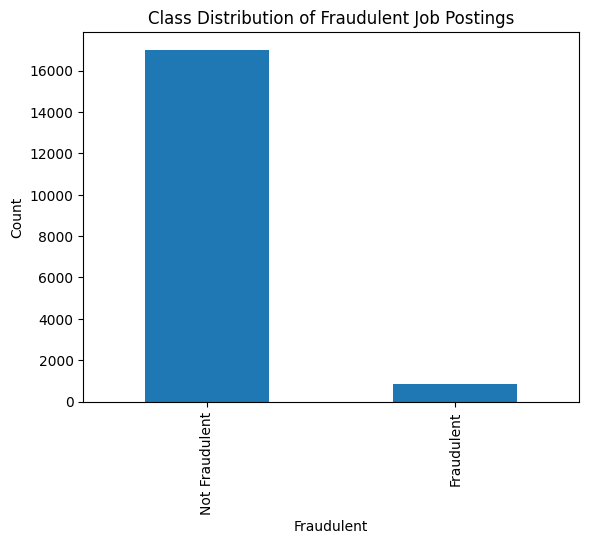

In [5]:
# class imbalance analysis
df['fraudulent'].value_counts().plot(kind='bar')
plt.title('Class Distribution of Fraudulent Job Postings')
plt.xlabel('Fraudulent')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Fraudulent', 'Fraudulent'])
plt.show()

- severe class imbalance with only 8.5% of the data being fraudulent, which will require careful handling during modeling to avoid bias towards the majority class.
-  The correlation analysis shows that 'telecommuting', 'has_company_logo', and 'has_questions' have very low correlation with 'fraudulent', suggesting that these features may not be strong predictors of fraudulence on their own.
- The high number of unique values in categorical columns like 'company_profile' and 'requirements' indicates that these features may require significant preprocessing (e.g., text vectorization) to be useful for modeling.
- Overall, the EDA reveals a highly imbalanced dataset with many unique categorical values and weak correlations among numerical features, which will necessitate careful feature engineering and model selection to effectively predict fraudulent job postings.

### Addressing Class imbalance, we can consider techniques such as:
1. Resampling: Oversampling the minority class (fraudulent) or undersampling the majority class (non-fraudulent) to create a more balanced dataset.
2. Using algorithms that are robust to class imbalance, such as Random Forests or Gradient Boosting Machines, which can handle imbalanced data better than simpler models.
3. Implementing cost-sensitive learning, where we assign a higher misclassification cost to the minority class to encourage the model to pay more attention to fraudulent cases during training. 